In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = {
    "Age": [28,45,35,50,30,42,26,48,38,55],
    "Income": [6.5,12,8,15,7,10,5.5,14,9,16],
    "CreditScore": [720,680,750,640,710,660,730,650,700,620],
    "LoanAmount": [5,10,6,12,5,9,4,11,7,13],
    "LoanTerm": [5,10,7,15,5,10,4,12,8,15],
    "EmploymentType": ["Salaried","Self-Employed","Salaried","Self-Employed","Salaried",
                       "Salaried","Salaried","Self-Employed","Salaried","Self-Employed"],
    "Default": [0,1,0,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

In [3]:
le = LabelEncoder()
df["EmploymentType"] = le.fit_transform(df["EmploymentType"])

In [4]:
X = df.drop("Default", axis=1)
y = df["Default"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [8]:
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



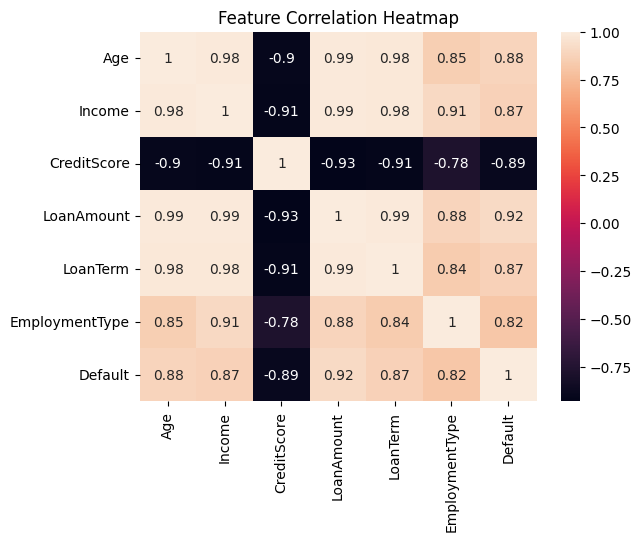

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

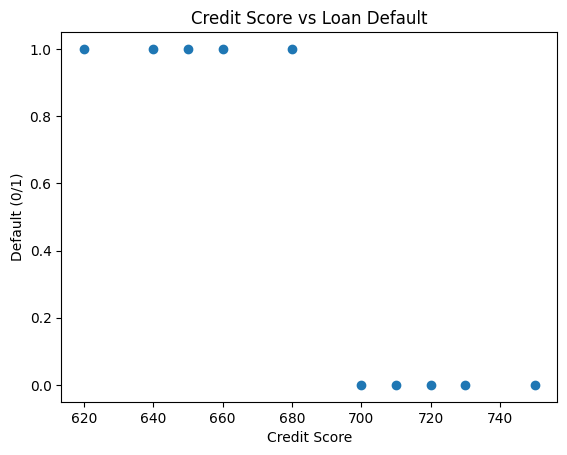

In [10]:
plt.figure()
plt.scatter(df["CreditScore"], df["Default"])
plt.xlabel("Credit Score")
plt.ylabel("Default (0/1)")
plt.title("Credit Score vs Loan Default")
plt.show()

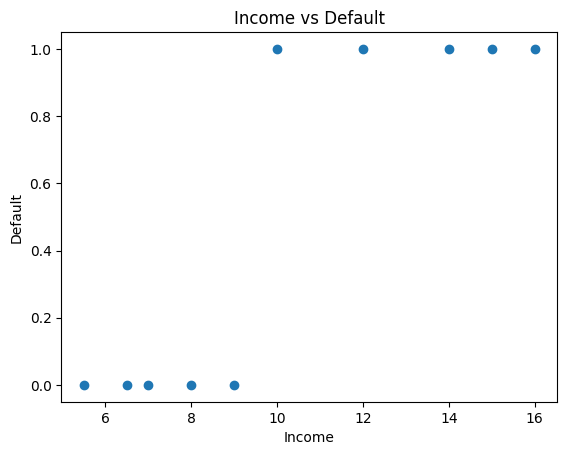

In [11]:
plt.figure()
plt.scatter(df["Income"], df["Default"])
plt.xlabel("Income")
plt.ylabel("Default")
plt.title("Income vs Default")
plt.show()

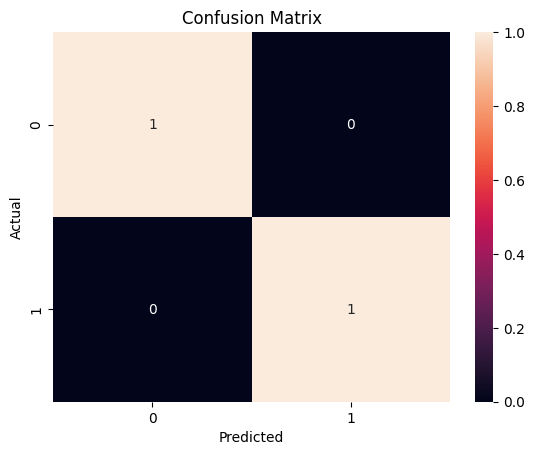

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()